# Chapter 3. 비지도 학습과 데이터 전처리

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.3 (main, Apr 19 2023, 23:54:32) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 1.5.3
matplotlib 버전: 3.7.1
SciFy 버전: 1.10.1
IPython 버전: 8.12.0
scikit-learn 버전: 1.2.2


## 3.5 군집
- **군집(clusterig)은 데이터셋을 클러스터라는 그룹으로 나누는 작업**
- 분류 알고리즘과 비슷하게 군집 알고리즘은 각 데이터 포인트가 어느 클러스터에 속하는지 할당(또는 예측)

### 3.5.1 k-평균 군집
- 데이터의 어떤 영역을 대표하는 **클러스터 중심(cluster center)을 찾음**
- 먼저 데이터 포인트를 가장 가까운 클러스터 중심에 할당하고, 클러스터에 할당된 데이터 포인트의 평균으로 클러스터 중심을 다시 지정 -> 클러스터에 할당되는 데이터 포인트에 변화가 없을 때 알고리즘 종료
- **새로운 데이터 포인트가 주어지면 가장 가까운 클러스터 중심을 할당**
- **단점**
> - k-평균의 단점 하나는 무작위 초기화를 사용하여 **알고리즘의 출력이 난수 초깃값에 따라 달라짐**, 기본적으로 scikit-learn에서는 서로 다른 난수 초깃값으로 10번 반복하여 최선(클러스터 분산 합이 작은) 결과를 만듦
> - 클러스터의 모양을 가정하고 있어서 활용 범위가 비교적 제한적이며, **찾으려 하는 클러스터의 개수를 지정해야 하는 점 -> 엘보우(elbow) 방법 이용 추천**
- **매개변수**
> - ***init* 매개변수에서 클러스터 초기화 방식 지정** 가능 : 기본값은 초기 클러스터 중심을 가능한 멀리 떨어지도록 만드는 'k-means++', 다른 값으로 'random'은 무작위로 초기 클러스터 중심 설정
> - ***max_iter* 매개변수(기본값 300)으로 알고리즘의 최대 반복 횟수를 지정**
> - ***n_clusters* 매개변수로 클러스트 수 지정**, 기본값은 8로 보통 기본값을 그대로 사용하지 않음

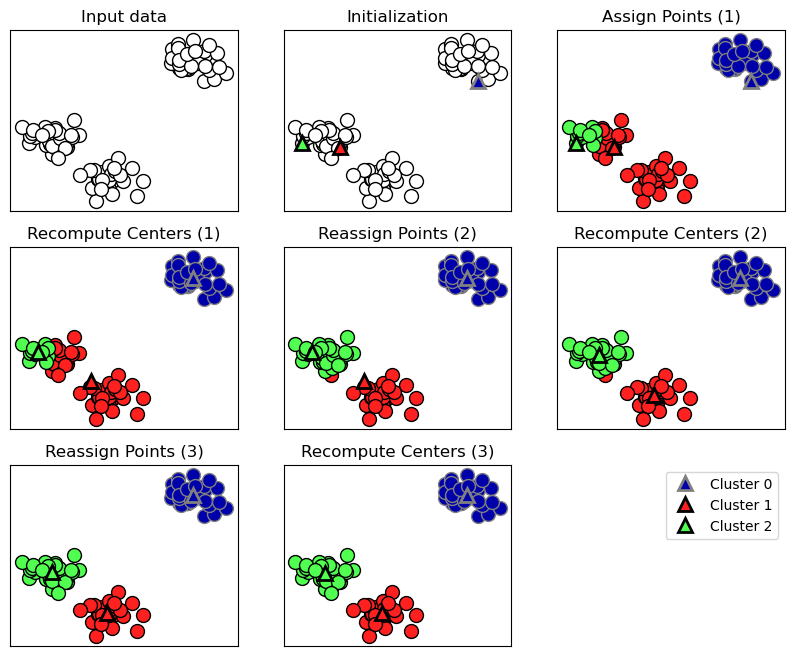

In [2]:
mglearn.plots.plot_kmeans_algorithm()

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 인위적으로 2차원 데이터를 생성
X, y = make_blobs(random_state=1)

# 군집 모델을 생성
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

KMeans(n_clusters=3)

> - 알고리즘을 적용하면 X에 담긴 각 훈련 데이터 포인트에 클러스터 레이블이 할당
> - ***kmeans.labels_* 속성에서 레이블 확인 가능**
> - ***predict* 메서드를 사용해 새로운 데이터의 클러스터 레이블 예측 가능**

In [3]:
print('클러스터 레이블:\n{}'.format(kmeans.labels_))
print('예측:\n{}'.format(kmeans.predict(X))) # 훈련 데이터 그대로 사용하므로 위와 결과 일치

클러스터 레이블:
[0 1 1 1 2 2 2 1 0 0 1 1 2 0 2 2 2 0 1 1 2 1 2 0 1 2 2 0 0 2 0 0 2 0 1 2 1
 1 1 2 2 1 0 1 1 2 0 0 0 0 1 2 2 2 0 2 1 1 0 0 1 2 2 1 1 2 0 2 0 1 1 1 2 0
 0 1 2 2 0 1 0 1 1 2 0 0 0 0 1 0 2 0 0 1 1 2 2 0 2 0]
예측:
[0 1 1 1 2 2 2 1 0 0 1 1 2 0 2 2 2 0 1 1 2 1 2 0 1 2 2 0 0 2 0 0 2 0 1 2 1
 1 1 2 2 1 0 1 1 2 0 0 0 0 1 2 2 2 0 2 1 1 0 0 1 2 2 1 1 2 0 2 0 1 1 1 2 0
 0 1 2 2 0 1 0 1 1 2 0 0 0 0 1 0 2 0 0 1 1 2 2 0 2 0]


> **(예시)**
> - cluster_centers_ 속성에 저장된 클러스터 중심을 삼각형으로 나타내기
> - n_clusters 조절을 통해 클러스터 수 조정 나타내기

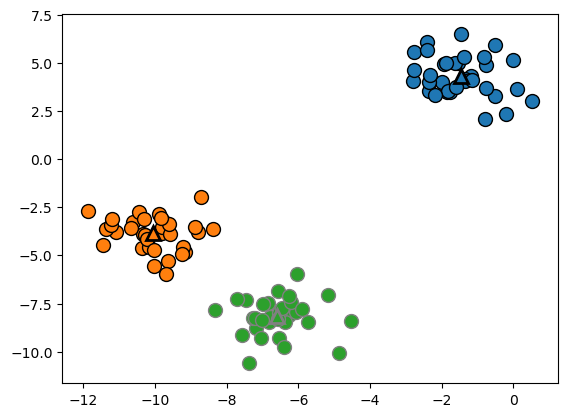

In [4]:
mglearn.discrete_scatter(X[:,0], X[:,1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], [0,1,2],
                         markers='^', markeredgewidth=2)

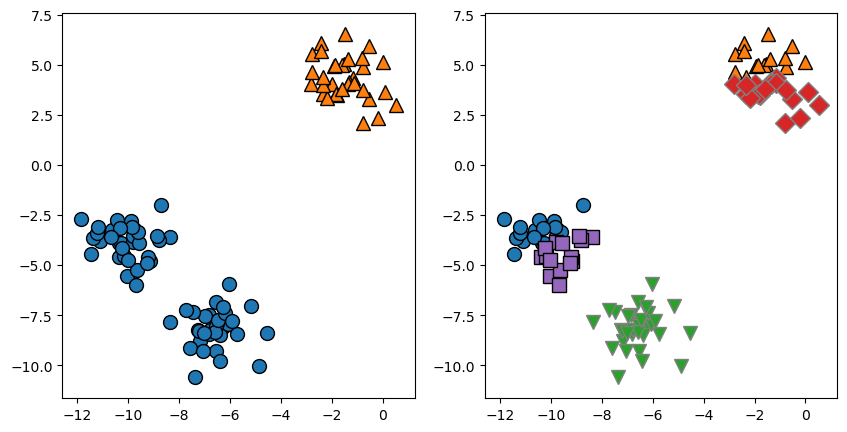

In [5]:
fig, axes = plt.subplots(1,2, figsize=(10,5))

# 두 개의 클러스터 중심을 사용
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
assignments = kmeans.labels_
mglearn.discrete_scatter(X[:,0], X[:,1], assignments, ax=axes[0])

# 다섯 개의 클러스터 중심을 사용
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
assignments = kmeans.labels_
mglearn.discrete_scatter(X[:,0], X[:,1], assignments, ax=axes[1])

#### <U>*벡터 양자와 또는 분해 메서드로서의 k-평균*</U>
- k-평균 알고리즘이 실패하는 경우
> - 데이터셋의 클러스터 개수를 정확하게 알고 있더라도 k-평균 알고리즘이 항상 이를 구분할 수 있는 것은 아님
> - 각 클러스트를 정의하는 것이 중심 하나뿐이므로 클러스터는 둥근 형태로 나타남 -> 비교적 간단한 형태를 구분
> - **k-평균은 모든 클러스터의 반경이 똑같다고 가정 -> 클러스터 중심 사이의 정확히 중간에 경계를 그림 -> 밀도가 다른 분포를 가진 클러스트들을 구분하기 어려움**
> - **k-평균은 클러스터에서 모든 방향이 똑같이 중요하다고 가정 -> 2차원에서 길쭉한 방향을 가지는 서로 다른 클러스트들을 구분하기 어려움** 

- **벡터 양자화(Vector quantization)**
> - PCA와 NMF 모두 데이터 포인트를 어떤 성분의 합으로 표현, 반면에 k-평균은 클러스트 중심으로 각 데이터 포인트를 표현
> - 이것을 각 데이터 포인트가 클러스트 중심, 즉 하나의 성분으로 표현된다고 볼 수 있음
> - **k-평균에서 각 데이터 포인트가 하나의 성분으로 분해되는 관점으로 보는 것을 벡터 양자화라고 함**

- **PCA, NMF, k-평균 비교**

In [6]:
# LFW 얼굴 이미지 불러와서 데이터 준비

from sklearn.datasets import fetch_lfw_people
people = fetch_lfw_people(min_faces_per_person = 20, resize=0.7)

image_shape = people.images[0].shape

mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

# 0-255 사이의 흑백 이미지의 픽셀 값을 0-1 스케일로 조정
# MinMaxScaler를 적용하는 것과 거의 같은 효과

X_people = X_people/255
print(X_people.shape)
print(y_people.shape)

(2063, 5655)
(2063,)


> - **PCA, NMF, k-평균에서 추출한 성분 비교**: 성분 100개씩

In [7]:
from sklearn.decomposition import PCA
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans

X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=42)

nmf = NMF(n_components=100, init='nndsvd', random_state=0, max_iter=1000, tol=1e-2)
nmf.fit(X_train)

pca = PCA(n_components=100, random_state=0)
pca.fit(X_train)

kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(X_train)

KMeans(n_clusters=100, random_state=0)

Text(0, 0.5, 'nmf')

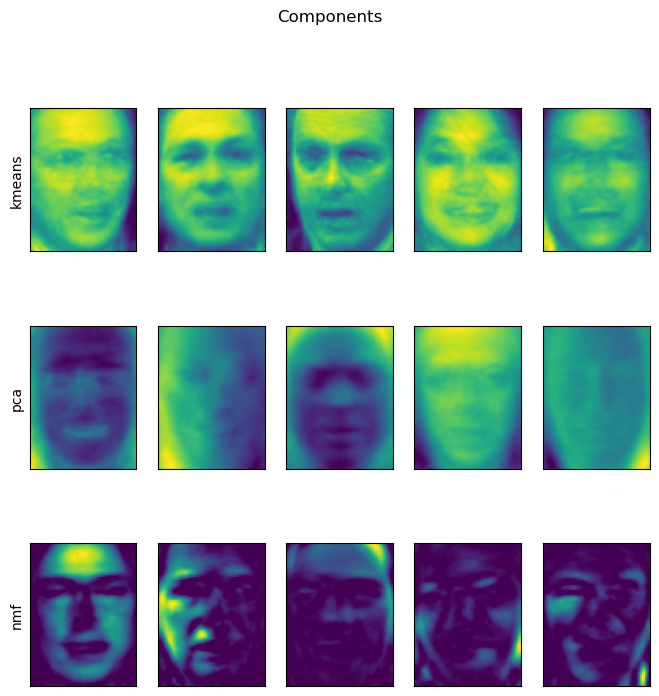

In [8]:
# 성분 시각화하여 비교
fig, axes = plt.subplots(3,5, figsize=(8,8), subplot_kw={'xticks':(), 'yticks':()})
fig.suptitle('Components')
for ax, comp_kmeans, comp_pca, comp_nmf in zip(axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
    ax[0].imshow(comp_kmeans.reshape(image_shape))
    ax[1].imshow(comp_pca.reshape(image_shape), cmap='viridis')
    ax[2].imshow(comp_nmf.reshape(image_shape))
    
axes[0,0].set_ylabel('kmeans')
axes[1,0].set_ylabel('pca')
axes[2,0].set_ylabel('nmf')

> - **100개의 성분으로 테스트 세트의 얼굴 재구성**

Text(0, 0.5, 'nmf')

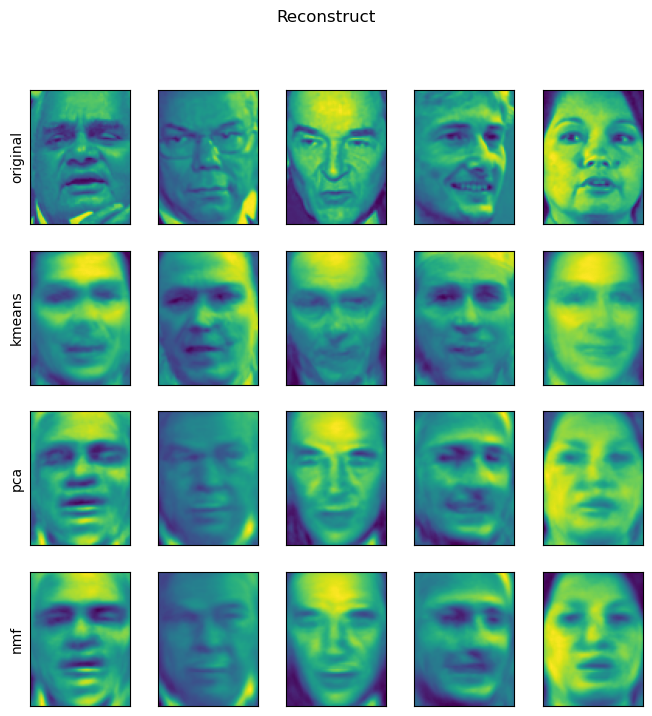

In [11]:
# 학습된 kmeans 알고리즘에 새로운 테스트 데이터를 가지고 클러스터 중심 재할당 개념 => 재구성은 훈련 세트에서 찾은 가장 가까운 클러스트 중심 하나를 가지고 이루어짐
X_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(X_test)] 

# PCA와 NMF는 새로운 테스트 데이터를 학습으로 도출된 새로운 성분 100개를 이용하여 구성(transform) 후 다시 원래 이미지 공간 내에 구현(inverse_transform)
X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test))
X_reconstructed_nmf = nmf.inverse_transform(nmf.transform(X_test))

fig, axes = plt.subplots(4,5, figsize=(8,8), subplot_kw={'xticks':(), 'yticks':()})
fig.suptitle('Reconstruct')
for ax, orig, rec_kmeans, rec_pca, rec_nmf in zip(axes.T, X_test, X_reconstructed_kmeans, X_reconstructed_pca, X_reconstructed_nmf):
    ax[0].imshow(orig.reshape(image_shape))
    ax[1].imshow(rec_kmeans.reshape(image_shape))
    ax[2].imshow(rec_pca.reshape(image_shape))
    ax[3].imshow(rec_nmf.reshape(image_shape))

axes[0,0].set_ylabel('original')
axes[1,0].set_ylabel('kmeans')
axes[2,0].set_ylabel('pca')
axes[3,0].set_ylabel('nmf')


> - **k-평균을 사용한 벡터 양자화의 흥미로운 면은 입력 데이터의 차원보다 더 많은 클러스터를 사용해 데이터 인코딩이 가능**
> - **two_moons 데이터를 활용하여 이를 검증**
>> - 원 데이터는 2차원이므로 PCA나 NMF로 1차원 축소하면 데이터 구조가 파괴되어 분석할 수 있는 여지가 없음
>> - 많은 클러스트 중심을 사용한 k-평균(벡터 양자화)로 2차원 데이터를 더 잘 표현할 수 있음

Cluster Label:
 [9 2 5 4 2 7 9 6 9 6 1 0 2 6 1 9 3 0 3 1 7 6 8 6 8 5 2 7 5 8 9 8 6 5 3 7 0
 9 4 5 0 1 3 5 2 8 9 1 5 6 1 0 7 4 6 3 3 6 3 8 0 4 2 9 6 4 8 2 8 4 0 4 0 5
 6 4 5 9 3 0 7 8 0 7 5 8 9 8 0 7 3 9 7 1 7 2 2 0 4 5 6 7 8 9 4 5 4 1 2 3 1
 8 8 4 9 2 3 7 0 9 9 1 5 8 5 1 9 5 6 7 9 1 4 0 6 2 6 4 7 9 5 5 3 8 1 9 5 6
 3 5 0 2 9 3 0 8 6 0 3 3 5 6 3 2 0 2 3 0 2 6 3 4 4 1 5 6 7 1 1 3 2 4 7 2 7
 3 8 6 4 1 4 3 9 9 5 1 7 5 8 2]


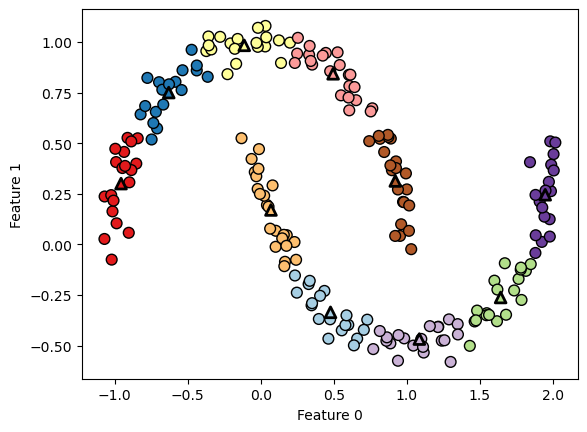

In [14]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:,0], X[:,1], c=y_pred, s=60, cmap='Paired', edgecolors='black')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=60, marker="^", c=range(kmeans.n_clusters), linewidth=2, cmap="Paired", edgecolors='black')

plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
print('Cluster Label:\n', y_pred)

- 위는 기존 2차원 데이터를 10차원으로 확장하여 표현한 것으로 이해할 수 있으며, 선형 모델 10개를 가지고 2개의 반달 모양 구분할 수 있음
- **클러스터 중심까지의 거리를 특성으로 사용하면 데이터를 더욱 잘 표현할 수 있음, 해당 데이터는 *kmeans.transform* 메서드의 반환 값임**

> - **클러스트 개수를 선택하는 방법: 엘보우(elbow method) 방법**
>> - **클러스트 개수를 늘려가면서 k-평균의 inertia 감소가 완만해지는 지점을 찾는 방식**, kmeans.inertia_ 속성에서 해당값 제공
>> - **inertia : 클러스터 중심에서 클러스터에 속한 각 샘플간의 제곱 거리의 합**

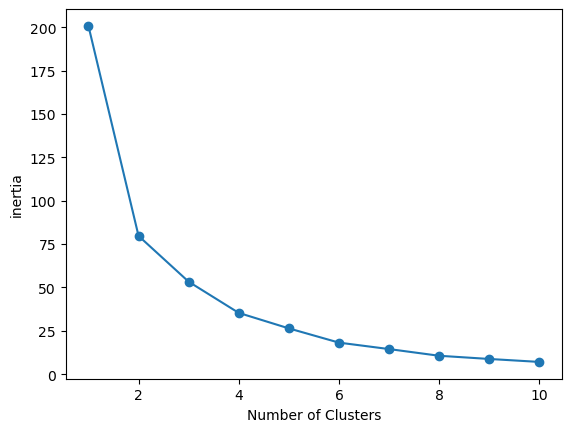

In [19]:
inertia = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('inertia')
plt.show()

- 그래프를 보면 클러스터 개수 2-4에서 inertial 값이 크게 꺾이는 것을 확인